In [107]:
from scipy.io import loadmat

data = loadmat("../data_drosophiles/Gap/gap_data_raw_dorsal_wt.mat", squeeze_me=True, struct_as_record=False)
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'data'])


In [108]:
emb = data['data']


embryos_sorted = sorted(emb, key=lambda e: e.age)
for em in embryos_sorted:
    print(em.age)

e0 = embryos_sorted[100]

print(e0._fieldnames)

38.1769079610532
38.25962369003342
38.2749809471006
38.441191051881404
38.90801216191008
38.94946126414391
38.951701089170854
38.96960236729269
39.04149434922023
39.0657430280727
39.13580897030831
39.24963163497707
39.290197008247475
39.2919321030635
39.33996975327727
39.35190986265326
39.38636150407388
39.427559530176914
39.49261464749625
39.49587854324415
39.51629130192627
39.53892770005699
39.614983866185625
39.6514177764913
39.707933754084074
39.7738555398213
39.864265875535004
39.91084197004049
39.93474019291528
39.95170438233656
39.957398716098425
39.97040372794152
39.993937831399734
40.013108198257214
40.07230781369215
40.073649742601944
40.187682430866765
40.211708447362426
40.240977460210175
40.472814988362096
40.49510511489311
40.513734830275055
40.564560858723226
40.69948670673863
40.7736081845102
40.88701594645838
40.92431000152435
40.958732129043206
40.97603265193015
41.02204985310342
41.05993617023168
41.31296644565855
41.44087641478715
41.46355810806222
41.50255447008325

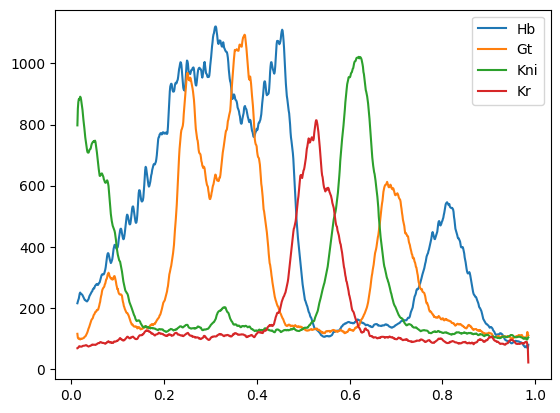

In [109]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 1, 1000)
plt.plot(x, e0.Hb, label="Hb")
plt.plot(x, e0.Gt, label="Gt")
plt.plot(x, e0.Kni, label="Kni")
plt.plot(x, e0.Kr, label="Kr")
plt.legend()

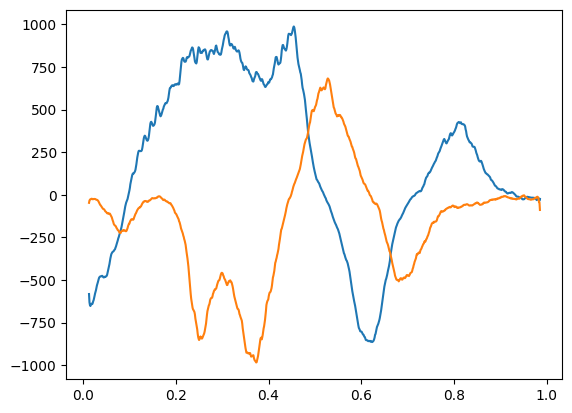

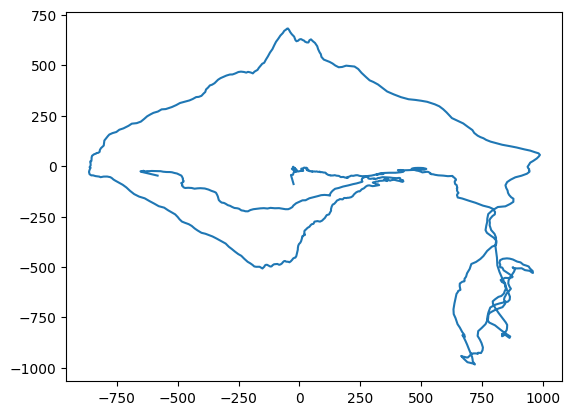

In [110]:
import matplotlib.pyplot as plt
import numpy as np

hbkni = e0.Hb - e0.Kni
krgt = e0.Kr - e0.Gt

x = np.linspace(0, 1, 1000)
plt.plot(x, hbkni, label="Hb - Kni")
plt.plot(x, krgt, label="Kr - Gt")
plt.show()


plt.plot(hbkni, krgt)

In [111]:
import numpy as np
from scipy.io import loadmat

# Charger
data = loadmat("../data_drosophiles/Gap/gap_data_raw_dorsal_wt.mat", squeeze_me=True, struct_as_record=False)
embryos = data['data']

# Trier par âge (important pour la dynamique temporelle)
embryos_sorted = sorted(embryos, key=lambda e: e.age)

genes = ['Hb', 'Kr', 'Kni', 'Gt']

blocks = []

for e in embryos_sorted:
    t = e.age
    
    # (1000, 4)
    profiles = np.stack([getattr(e, g) for g in genes], axis=1)
    
    # colonne temps (1000, 1)
    time_col = np.full((profiles.shape[0], 1), t)
    
    # (1000, 5)
    block = np.hstack([profiles, time_col])
    
    blocks.append(block)

# (102, 1000, 5)
A = np.stack(blocks, axis=0)

print("Shape initiale :", A.shape)

# masque des positions propres (sur tous les embryons et tous les gènes)
mask = ~np.isnan(A[:, :, :4]).any(axis=(0, 2))

A_clean = A[:, mask, :]

print("Shape après nettoyage :", A_clean.shape)

Shape initiale : (102, 1000, 5)
Shape après nettoyage : (102, 968, 5)


In [112]:
print(A_clean[70, 400])

[1281.81818182  150.30909091  126.12727273  336.65454545   43.98069398]


In [113]:
np.save("gene_expression_with_time.npy", A_clean)